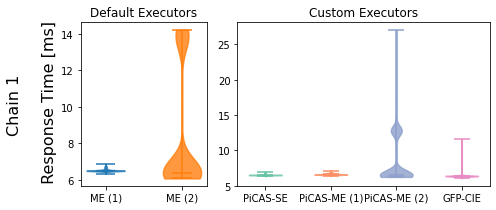

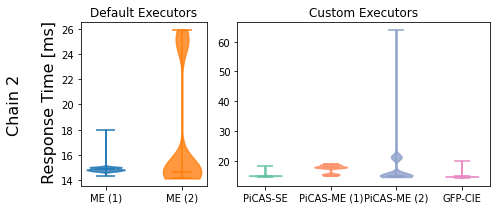

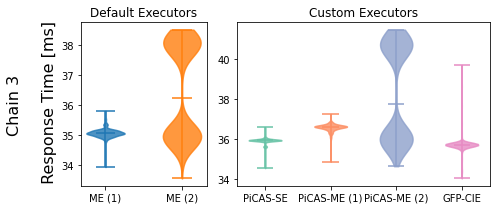

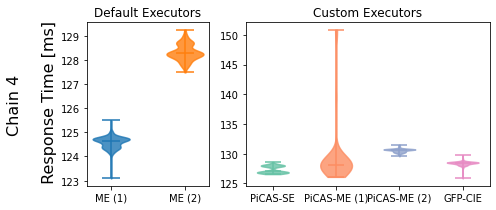

In [12]:
# Old version

import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

TARGET_NUM_LOAD_TASKS = '_0'
FILTERS = ['default_st']

RESULT_DIR = "/home/atsushi/ros2-picas/results/"
TARGET_LABELS = ['C1R1_12_latency', 'C2R3_11_latency', 'C3R2_7_latency', 'C4R3_4_latency']
PLOT_ORDER_MAP = {
    "Default Executors": [
        # f'case_study_default_st4{TARGET_NUM_LOAD_TASKS}',
        f'case_study_default_mt4{TARGET_NUM_LOAD_TASKS}',
        f'case_study_default_mt_separate4{TARGET_NUM_LOAD_TASKS}',
    ],
    "Custom Executors": [
        f'case_study_picas_st4{TARGET_NUM_LOAD_TASKS}',
        f'case_study_picas_mt4{TARGET_NUM_LOAD_TASKS}',
        f'case_study_picas_mt_separate4{TARGET_NUM_LOAD_TASKS}',
        f'case_study_cie_4{TARGET_NUM_LOAD_TASKS}',
    ]
}
X_LABEL_MAP = {
    f'case_study_cie_4{TARGET_NUM_LOAD_TASKS}': 'GFP-CIE',
    f'case_study_picas_mt4{TARGET_NUM_LOAD_TASKS}': 'PiCAS-ME (1)',
    f'case_study_picas_mt_separate4{TARGET_NUM_LOAD_TASKS}': 'PiCAS-ME (2)',
    f'case_study_picas_st4{TARGET_NUM_LOAD_TASKS}': 'PiCAS-SE',
    f'case_study_default_mt_separate4{TARGET_NUM_LOAD_TASKS}': 'ME (2)',
    f'case_study_default_mt4{TARGET_NUM_LOAD_TASKS}': 'ME (1)',
    # f'case_study_default_st4{TARGET_NUM_LOAD_TASKS}': 'SE',
}
OUTPUT_DIR = "/home/atsushi/ros2-picas/figure"


def read_rt_data(path, key, combined_data):
    with open(path, 'r') as file:
        for line in file:
            parts = line.strip().split()
            if len(parts) != 3 or int(parts[2]) <= 10:
                continue
            label, value = parts[0], int(parts[1])
            if label in combined_data:
                combined_data[label][key].append(value / 1000)  # μs -> ms


# データ読み込みの準備
keys = [dir.split('/')[-1] for dir in os.listdir(RESULT_DIR)
        if TARGET_NUM_LOAD_TASKS in dir and all(f not in dir for f in FILTERS)]
combined_data = {label: {key: [] for key in keys} for label in TARGET_LABELS}

for dir in os.listdir(RESULT_DIR):
    if TARGET_NUM_LOAD_TASKS not in dir or any(f in dir for f in FILTERS):
        continue

    key = dir.split('/')[-1]
    target_file = os.path.join(RESULT_DIR, dir, 'R.txt')
    read_rt_data(target_file, key, combined_data)

# グラフの描画
for label in TARGET_LABELS:
    default_keys = [key for key in keys if key.startswith("case_study_default_")]
    other_keys = [key for key in keys if not key.startswith("case_study_default_")]

    default_data = [combined_data[label][key] for key in default_keys]
    other_data = [combined_data[label][key] for key in other_keys]

    fig = plt.figure(figsize=(7, 3))
    spec = gridspec.GridSpec(nrows=1, ncols=2, width_ratios=[1, 2])  # 左狭く、右広く

    axes = [fig.add_subplot(spec[0]), fig.add_subplot(spec[1])]

    for idx, (ax, data_group, group_keys, title, cmap_name) in enumerate(zip(
        axes,
        [default_data, other_data],
        [default_keys, other_keys],
        ["Default Executors", "Custom Executors"],
        ['tab10', 'Set2']  # 異なるカラーマップを指定
    )):
        ordered_keys = PLOT_ORDER_MAP.get(title, group_keys)
        ordered_data = [combined_data[label][key] for key in ordered_keys]

        cmap = plt.get_cmap(cmap_name)
        colors = [cmap(i) for i in range(len(ordered_data))]

        parts = ax.violinplot(ordered_data, showmeans=False, showmedians=True)

        for body, color in zip(parts['bodies'], colors):
            body.set_facecolor(color)
            body.set_edgecolor(color)
            body.set_linewidth(1.5)
            body.set_alpha(0.8)

        for line_key in ['cmedians', 'cmeans', 'cbars', 'cmins', 'cmaxes']:
            if line_key in parts:
                lines = parts[line_key]
                if isinstance(lines, list):  # 一般的には list of Line2D
                    for line, color in zip(lines, colors):
                        line.set_color(color)
                        line.set_linewidth(1.5)
                else:
                    # 例：cbars や cmeans は LineCollection の可能性あり
                    lines.set_color(colors)
                    lines.set_linewidth(1.5)

        ax.set_xticks([i + 1 for i in range(len(ordered_keys))])
        ax.set_xticklabels(
            [X_LABEL_MAP.get(key, key) for key in ordered_keys],
            rotation=0,
            # ha='right'
        )
        ax.set_title(title)
        ax.grid(False)

    if TARGET_NUM_LOAD_TASKS == '_0':
        axes[0].set_ylabel(
            f"{label[:2].replace('C', 'Chain ')}\n\n Response Time [ms]", fontsize=16)
    # fig.suptitle(f'{label[:2].replace("C", "Chain ")}', fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 1.04])
    # plt.show()
    plt.savefig(f'{OUTPUT_DIR}/{label[:2]}{TARGET_NUM_LOAD_TASKS}.pdf')

In [ ]:
# import os
# import matplotlib.pyplot as plt

# # 設定
# TARGET_NUM_LOAD_TASKS = '_0'
# FILTERS = ['default_st']
# RESULT_DIR = "/home/atsushi/ros2-picas/results/"
# OUTPUT_DIR = "/home/atsushi/ros2-picas/figure"

# TARGET_LABELS = [
#     'C1R1_12_latency',
#     'C2R3_11_latency',
#     'C3R2_7_latency',
#     'C4R3_4_latency'
# ]

# # 全Executor順序付きマップ
# ORDERED_KEYS = [
#     f'case_study_default_mt4{TARGET_NUM_LOAD_TASKS}',
#     f'case_study_default_mt_separate4{TARGET_NUM_LOAD_TASKS}',
#     f'case_study_picas_st4{TARGET_NUM_LOAD_TASKS}',
#     f'case_study_picas_mt4{TARGET_NUM_LOAD_TASKS}',
#     f'case_study_picas_mt_separate4{TARGET_NUM_LOAD_TASKS}',
#     f'case_study_cie_4{TARGET_NUM_LOAD_TASKS}',
# ]

# X_LABEL_MAP = {
#     f'case_study_cie_4{TARGET_NUM_LOAD_TASKS}': 'GFP-CIE',
#     f'case_study_picas_mt4{TARGET_NUM_LOAD_TASKS}': 'PiCAS-ME (1)',
#     f'case_study_picas_mt_separate4{TARGET_NUM_LOAD_TASKS}': 'PiCAS-ME (2)',
#     f'case_study_picas_st4{TARGET_NUM_LOAD_TASKS}': 'PiCAS-SE',
#     f'case_study_default_mt_separate4{TARGET_NUM_LOAD_TASKS}': 'ME (2)',
#     f'case_study_default_mt4{TARGET_NUM_LOAD_TASKS}': 'ME (1)',
# }


# def read_rt_data(path, key, combined_data):
#     with open(path, 'r') as file:
#         for line in file:
#             parts = line.strip().split()
#             if len(parts) != 3 or int(parts[2]) <= 10:
#                 continue
#             label, value = parts[0], int(parts[1])
#             if label in combined_data:
#                 combined_data[label][key].append(value / 1000)  # μs -> ms


# # データ読み込み
# keys = [
#     d for d in os.listdir(RESULT_DIR)
#     if TARGET_NUM_LOAD_TASKS in d and all(f not in d for f in FILTERS)
# ]

# combined_data = {
#     label: {key: [] for key in keys} for label in TARGET_LABELS
# }

# for d in keys:
#     path = os.path.join(RESULT_DIR, d, 'R.txt')
#     read_rt_data(path, d, combined_data)

# # 図の生成
# for label in TARGET_LABELS:
#     available_keys = [key for key in ORDERED_KEYS if key in keys]
#     data = [combined_data[label][key] for key in available_keys]

#     fig, ax = plt.subplots(figsize=(8, 3.5))

#     # カラーマップ
#     cmap = plt.get_cmap('Set2')
#     colors = [cmap(i) for i in range(len(data))]

#     # バイオリンプロット
#     parts = ax.violinplot(data, showmeans=False, showmedians=True)

#     for body, color in zip(parts['bodies'], colors):
#         body.set_facecolor(color)
#         body.set_edgecolor(color)
#         body.set_linewidth(1.5)
#         body.set_alpha(0.8)

#     for line_key in ['cmedians', 'cmeans', 'cbars', 'cmins', 'cmaxes']:
#         if line_key in parts:
#             lines = parts[line_key]
#             if isinstance(lines, list):
#                 for line, color in zip(lines, colors):
#                     line.set_color(color)
#                     line.set_linewidth(1.5)
#             else:
#                 lines.set_color(colors)
#                 lines.set_linewidth(1.5)

#     # 軸設定
#     ax.set_xticks([i + 1 for i in range(len(available_keys))])
#     ax.set_xticklabels(
#         [X_LABEL_MAP.get(key, key) for key in available_keys],
#         rotation=30, ha='right'
#     )
#     ax.set_ylabel(f"{label[:2]}'s Response Time [ms]", fontsize=12)
#     ax.grid(False)

#     plt.tight_layout(rect=[0, 0.03, 1, 1.02])
#     plt.savefig(f'{OUTPUT_DIR}/{label[:2]}{TARGET_NUM_LOAD_TASKS}.pdf')
#     plt.close()

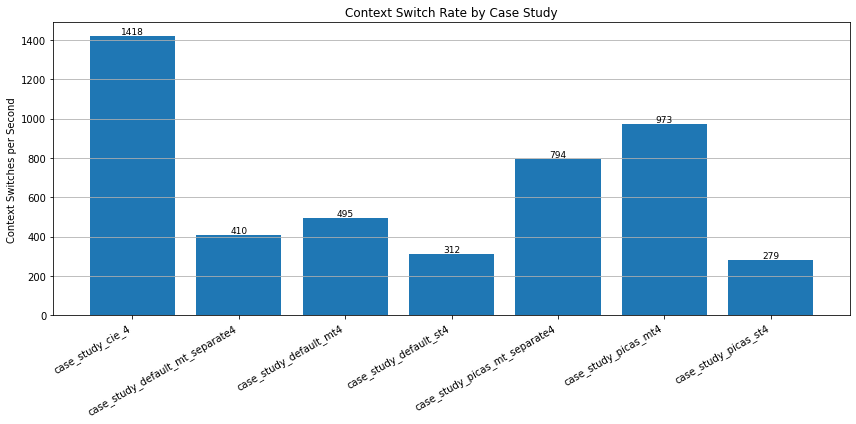

In [ ]:
import os
import re
import matplotlib.pyplot as plt


def parse_perf_stat(filepath):
    """perf_stat.txt から context-switches と time elapsed を抽出"""
    with open(filepath, 'r') as f:
        content = f.read()

    # コンテキストスイッチ数と経過時間を抽出
    cs_match = re.search(r'([\d,]+)\s+context-switches', content)
    time_match = re.search(r'([\d.]+)\s+seconds time elapsed', content)

    if cs_match and time_match:
        context_switches = int(cs_match.group(1).replace(',', ''))
        time_elapsed = float(time_match.group(1))
        return context_switches / time_elapsed if time_elapsed > 0 else None
    return None


def plot_context_switch_rates(filepaths):
    """各ファイルから1秒あたりのコンテキストスイッチを計算し、棒グラフに描画"""
    labels = []
    values = []

    for filepath in filepaths:
        rate = parse_perf_stat(filepath)
        if rate is not None:
            # ラベルには親ディレクトリ名を使用
            dir_name = os.path.basename(os.path.dirname(filepath))
            labels.append(dir_name)
            values.append(rate)

    plt.figure(figsize=(12, 6))
    bars = plt.bar(labels, values)

    # 棒の上に数値を表示（整数で）
    for bar, value in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 f'{value:.0f}', ha='center', va='bottom', fontsize=9)

    plt.ylabel('Context Switches per Second')
    plt.title('Context Switch Rate by Case Study')
    plt.xticks(rotation=30, ha='right')
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()


# 使用例
input_files = [
    '/home/atsushi/ros2-picas/results/case_study_cie_4/perf_stat.txt',
    '/home/atsushi/ros2-picas/results/case_study_default_mt_separate4/perf_stat.txt',
    '/home/atsushi/ros2-picas/results/case_study_default_mt4/perf_stat.txt',
    '/home/atsushi/ros2-picas/results/case_study_default_st4/perf_stat.txt',
    '/home/atsushi/ros2-picas/results/case_study_picas_mt_separate4/perf_stat.txt',
    '/home/atsushi/ros2-picas/results/case_study_picas_mt4/perf_stat.txt',
    '/home/atsushi/ros2-picas/results/case_study_picas_st4/perf_stat.txt',
]

plot_context_switch_rates(input_files)